# 05b — Baseline: Decision Tree
**RouteRight AI — Stage 6 (Model Development)** | Owner: *(write team member name / ID here)*

This notebook runs **one** baseline model — **Decision Tree** — in two variants (unweighted and class-weighted) and records its results.
Everything that must be identical across the four models (data, `TimeSeriesSplit` folds, threshold, metric definitions, seed, weighting logic) lives in **`baseline_common.py`**, so the models are compared on exactly the same footing. The four results are merged in `05e_Baseline_Comparison.ipynb`.

* **Validation:** 5-fold `TimeSeriesSplit` on `train.csv` only — each fold trains on earlier rows and validates on the next block.
* **Metrics:** PR-AUC and F1 are primary (test set is more imbalanced than train: 37% vs 47% positive); accuracy, precision, recall, ROC-AUC also reported.
* **Test set:** never loaded. Kept sealed until `07_Model_Evaluation.ipynb`.
* **Baseline = library defaults.** Tuning is Stage 7.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

import baseline_common as bc

MODEL_NAME = "Decision Tree"
print("Project root:", bc.ROOT)

Project root: C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor


## 2. Load training data and sanity checks
Only `train.csv` is loaded. `load_train()` asserts no missing values, all-numeric features, and **chronological row order** (the assumption `TimeSeriesSplit` depends on; `opened_month` is the only time signal in this file).

In [2]:
X, y, train = bc.load_train()

Shape: (21180, 110) | missing: 0 | exact duplicate rows: 1865
Positive rate: 0.4712  (neg:pos = 1.12:1)
Rows per month (file order): {2.0: 207, 3.0: 8995, 4.0: 7934, 5.0: 4044}
Chronological order check: PASSED


## 3. Validation folds
Fold 1 trains on only ~3,500 rows (mostly Feb/March), so per-fold scores are shown, not only the mean.
**Caveat:** train contains 1,865 exact duplicate rows; a duplicate can sit on both sides of a fold boundary, making validation scores slightly optimistic (most visibly for trees). They are kept, not dropped, to preserve the documented class balance.

In [3]:
bc.fold_table(X, y)

,fold,n_train,n_val,train_pos_rate,val_pos_rate,val_months
0,1,3530,3530,0.5521,0.6110,[3]
1,2,7060,3530,0.5816,0.4530,"[3, 4]"
2,3,10590,3530,0.5387,0.4261,[4]
3,4,14120,3530,0.5106,0.3742,"[4, 5]"
4,5,17650,3530,0.4833,0.4110,[5]


## Why a Decision Tree, and how it is set up
* **Role:** the **interpretable nonlinear** model — it produces readable if/then rules, and shows whether simple splits on category / assignment group carry the signal.
* **Settings:** scikit-learn defaults — **no depth limit**, `min_samples_leaf=1`. This is deliberate: the baseline shows what an unconstrained tree does, motivating the regularisation searched in Stage 7 (`max_depth`, `min_samples_leaf`, `ccp_alpha`).
* **Scaling:** not needed (splits are threshold-based).
* **Weighted variant:** `class_weight="balanced"`.
* **Expected:** severe overfitting — an unconstrained tree can memorise every training row.

In [4]:
bc.MODEL_FACTORIES[MODEL_NAME]("balanced")     # the weighted variant; unweighted is identical with class_weight=None

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_f

## 4. Cross-validated results

In [5]:
folds_df, oof_df = bc.run_cv(MODEL_NAME, X, y)
summary = bc.summarize(folds_df)
summary[["model", "variant", "pr_auc", "pr_auc_std", "f1", "recall", "precision", "accuracy", "roc_auc", "train_accuracy", "fit_seconds"]]

cross-validated: Decision Tree (unweighted)
cross-validated: Decision Tree (weighted)


,model,variant,pr_auc,pr_auc_std,f1,recall,precision,accuracy,roc_auc,train_accuracy,fit_seconds
0,Decision Tree,weighted,0.5515,0.0689,0.6188,0.6344,0.6063,0.6509,0.6429,0.9894,0.42
1,Decision Tree,unweighted,0.5468,0.0697,0.6145,0.6361,0.5971,0.6440,0.6375,0.9894,0.45


Per-fold PR-AUC next to the **no-skill level** (a model with no skill scores the positive rate of that validation block, so compare each fold against its own line, not against other folds).

In [6]:
bc.per_fold_view(folds_df)

,n_train,no_skill_pr_auc,pr_auc_unweighted,pr_auc_weighted
fold,,,,
1,3530,0.611,0.665,0.668
2,7060,0.453,0.544,0.551
3,10590,0.426,0.492,0.494
4,14120,0.374,0.501,0.507
5,17650,0.411,0.532,0.537


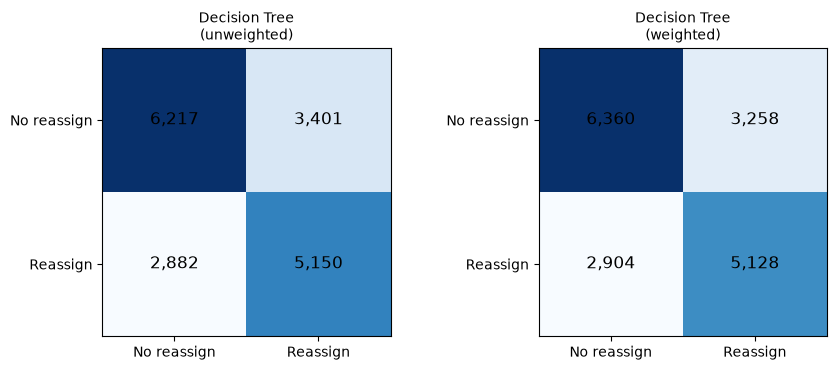

In [7]:
# Confusion matrices from pooled out-of-fold predictions (validation blocks of folds 1-5). Rows = actual, columns = predicted.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, variant in zip(axes, ["unweighted", "weighted"]):
    part = oof_df[oof_df.variant == variant]
    cm = confusion_matrix(part.y_true, part.y_pred)
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No reassign", "Reassign"]); ax.set_yticklabels(["No reassign", "Reassign"])
    ax.set_title(f"{MODEL_NAME}\n({variant})", fontsize=10)
plt.tight_layout(); plt.savefig(bc.OUT_DIR / f"baseline_{bc.slug(MODEL_NAME)}_confusion.png", dpi=130); plt.show()

## 5. Fit on the full training set and save
The model is refit on **all** of `train.csv` and saved to `models/baseline/`. Full-train accuracy is used in the comparison notebook to check against the training-accuracy ceiling. **No test data is used.**

In [8]:
full_df, fitted = bc.full_fit_and_save(MODEL_NAME, X, y)
bc.save_outputs(MODEL_NAME, folds_df, oof_df, full_df)
full_df

Saved results for Decision Tree to C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor\docs\deliverables_eval2


,model,variant,train_accuracy_full,train_f1_full
0,Decision Tree,unweighted,0.9896,0.989
1,Decision Tree,weighted,0.9896,0.989


## 6. Interpretation — tree size and feature importance

Fitted tree: depth = 68, leaves = 5,734, training rows = 21,180
Full-train accuracy: 0.9896 | CV validation accuracy: 0.644


,gini_importance
opened_hour,0.1409
opened_day_of_week,0.0913
assignment_group_20,0.0450
opened_month,0.0430
u_symptom_534,0.0286
assignment_group_64,0.0261
opened_by_Other,0.0217
location_161,0.0181
location_Other,0.0176
opened_by_17,0.0175


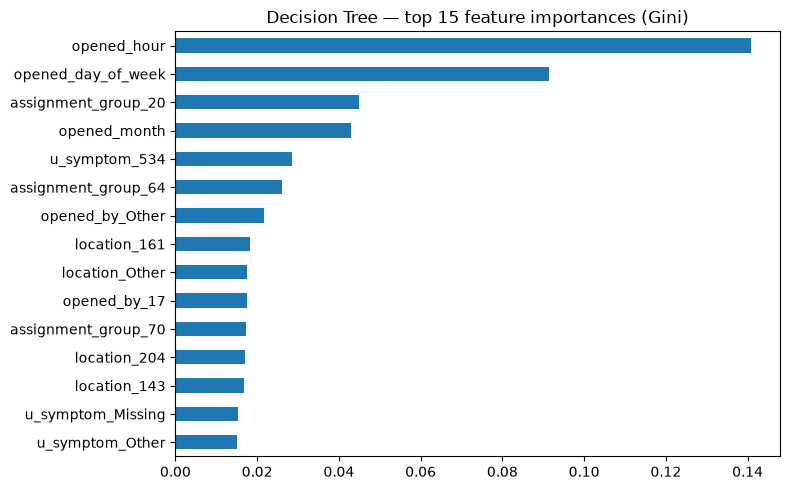

In [9]:
dt = fitted["unweighted"]
print(f"Fitted tree: depth = {dt.get_depth()}, leaves = {dt.get_n_leaves():,}, training rows = {len(X):,}")
print("Full-train accuracy:", full_df.loc[full_df.variant == "unweighted", "train_accuracy_full"].iloc[0],
      "| CV validation accuracy:", summary.loc[summary.variant == "unweighted", "accuracy"].iloc[0])

imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
top = imp.head(15)
display(top.round(4).to_frame("gini_importance"))
top.iloc[::-1].plot.barh(figsize=(8, 5), title="Decision Tree — top 15 feature importances (Gini)")
plt.tight_layout(); plt.savefig(bc.OUT_DIR / "baseline_decision_tree_importance.png", dpi=130); plt.show()

## 7. Observations (numbers from the run above — re-check if you change anything)
1. **Severe overfitting.** Full-train accuracy ≈ 0.99 versus CV validation accuracy ≈ 0.64 and CV PR-AUC ≈ 0.55. A tree with no depth limit grows until nearly every training row has its own leaf.
2. **Weakest of the four** (PR-AUC ≈ 0.55 vs ≈ 0.72–0.74 for the others) — it is only modestly above the no-skill reference (≈ 0.455). Its F1 (≈ 0.61) is much closer to the other models than its PR-AUC is, because F1 depends on the hard 0/1 predictions at threshold 0.5, while PR-AUC needs a good *ranking* of tickets, which a fully grown tree (leaves with almost pure, tiny groups) provides poorly.
3. **Highly unstable across folds** (PR-AUC 0.67 in fold 1 down to 0.49–0.53 later), a typical high-variance signature.
4. **Importances are misleading here.** `opened_hour` and `opened_day_of_week` rank first, but Gini importance favours features with many possible split points, and the README found numeric features carry little linear signal. An overfit tree uses them to carve out individual rows, so treat this ranking with caution.
5. **Class weighting made no meaningful difference** (PR-AUC 0.5468 vs 0.5489).
6. **Stage 7 plan:** constrain the tree (`max_depth`, `min_samples_leaf`, `ccp_alpha`) via `RandomizedSearchCV` + `TimeSeriesSplit`. Even tuned, a single tree is unlikely to beat the ensembles; its value is interpretability.